# Training an MNIST classifier and attacking it with FGSM

This notebook is self-contained: it downloads MNIST, trains the classifier used by the PyTorch FGSM tutorial, saves the learned weights, reloads them into a fresh model, and evaluates Fast Gradient Sign Method attacks.

References:

- [PyTorch FGSM tutorial](https://docs.pytorch.org/tutorials/beginner/fgsm_tutorial.html)
- [PyTorch MNIST example](https://github.com/pytorch/examples/tree/main/mnist)
- [Explaining and Harnessing Adversarial Examples](https://arxiv.org/abs/1412.6572)


## 1. Setup and reproducibility

All paths are kept under the repository's torch directory. Dataset files go in torch/data/MNIST and the trained weights go in torch/models/mnist_cnn_state_dict.pt.

In [1]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 1
BATCH_SIZE = 64
TEST_BATCH_SIZE = 1_000
ATTACK_BATCH_SIZE = 256
EPOCHS = 14
LEARNING_RATE = 1.0
LR_GAMMA = 0.7
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081
EPSILONS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device('cpu')
)

working_dir = Path.cwd().resolve()
torch_dir = working_dir if working_dir.name == 'torch' else working_dir / 'torch'
data_dir = torch_dir / 'data'
model_dir = torch_dir / 'models'
model_path = model_dir / 'mnist_cnn_state_dict.pt'
data_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)

print(f'Device: {device}')
print(f'Dataset directory: {data_dir}')
print(f'Model path: {model_path}')


Device: mps
Dataset directory: /Users/rad/dev/minor/ml/llmsfs/torch/data
Model path: /Users/rad/dev/minor/ml/llmsfs/torch/models/mnist_cnn_state_dict.pt


## 2. Download and load MNIST

The training split has 60,000 images and the test split has 10,000. Setting download=True makes this cell download missing files and reuse them on later runs. Images are converted to tensors and normalized using the standard MNIST mean and standard deviation.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),
])

train_dataset = datasets.MNIST(
    root=str(data_dir),
    train=True,
    download=True,
    transform=transform,
)
test_dataset = datasets.MNIST(
    root=str(data_dir),
    train=False,
    download=True,
    transform=transform,
)

loader_generator = torch.Generator().manual_seed(SEED)
pin_memory = device.type == 'cuda'

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
    num_workers=0,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)
attack_loader = DataLoader(
    test_dataset,
    batch_size=ATTACK_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

print(f'Training examples: {len(train_dataset):,}')
print(f'Test examples: {len(test_dataset):,}')
print(f'Training batches per epoch: {len(train_loader):,}')


Training examples: 60,000
Test examples: 10,000
Training batches per epoch: 938


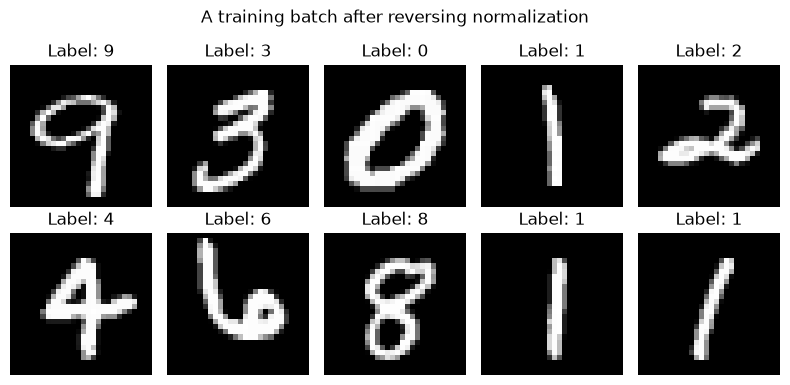

In [3]:
sample_images, sample_labels = next(iter(train_loader))
sample_images = (sample_images * MNIST_STD + MNIST_MEAN).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for axis, image, label in zip(axes.flat, sample_images[:10], sample_labels[:10]):
    axis.imshow(image.squeeze(), cmap='gray', vmin=0, vmax=1)
    axis.set_title(f'Label: {label.item()}')
    axis.axis('off')
fig.suptitle('A training batch after reversing normalization')
plt.tight_layout()
plt.show()


## 3. Define the classifier

This is the same convolutional architecture used by the PyTorch MNIST and FGSM examples. It returns log-probabilities for digits 0 through 9, so training uses negative log-likelihood loss.

In [4]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.50)
        self.fc1 = nn.Linear(9_216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        return F.log_softmax(self.fc2(x), dim=1)


In [5]:
model = Net().to(device)
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print(model)
print(f'Trainable parameters: {trainable_parameters:,}')


Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Trainable parameters: 1,199,882


## 4. Train and evaluate

Each epoch makes one pass over the training set. Evaluation disables dropout and gradient tracking, then reports average loss and accuracy on the held-out test set.

In [6]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0

    for data, target in loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad(set_to_none=True)
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.size(0)
        correct += output.argmax(dim=1).eq(target).sum().item()

    sample_count = len(loader.dataset)
    return total_loss / sample_count, correct / sample_count


@torch.inference_mode()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    correct = 0

    for data, target in loader:
        data = data.to(device)
        target = target.to(device)
        output = model(data)
        total_loss += F.nll_loss(output, target, reduction='sum').item()
        correct += output.argmax(dim=1).eq(target).sum().item()

    sample_count = len(loader.dataset)
    return total_loss / sample_count, correct / sample_count


In [7]:
optimizer = optim.Adadelta(model.parameters(), lr=LEARNING_RATE)
scheduler = StepLR(optimizer, step_size=1, gamma=LR_GAMMA)
history = []


In [8]:
training_started = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, device)
    test_loss, test_accuracy = evaluate(model, test_loader, device)
    current_lr = optimizer.param_groups[0]['lr']

    history.append({
        'epoch': epoch,
        'learning_rate': current_lr,
        'train_loss': train_loss,
        'train_accuracy': train_accuracy,
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
    })

    print(
        'Epoch {:02d}/{:02d} | train loss {:.4f}, accuracy {:.2%} | '
        'test loss {:.4f}, accuracy {:.2%} | lr {:.5f}'.format(
            epoch,
            EPOCHS,
            train_loss,
            train_accuracy,
            test_loss,
            test_accuracy,
            current_lr,
        )
    )
    scheduler.step()

elapsed = time.perf_counter() - training_started
print(f'Training completed in {elapsed:.1f} seconds.')


Epoch 01/14 | train loss 0.1926, accuracy 94.22% | test loss 0.0497, accuracy 98.38% | lr 1.00000


Epoch 02/14 | train loss 0.0721, accuracy 97.92% | test loss 0.0342, accuracy 98.76% | lr 0.70000


Epoch 03/14 | train loss 0.0518, accuracy 98.44% | test loss 0.0297, accuracy 98.89% | lr 0.49000


Epoch 04/14 | train loss 0.0405, accuracy 98.76% | test loss 0.0307, accuracy 98.97% | lr 0.34300


Epoch 05/14 | train loss 0.0350, accuracy 98.99% | test loss 0.0301, accuracy 99.08% | lr 0.24010


...

Epoch 10/14 | train loss 0.0261, accuracy 99.22% | test loss 0.0253, accuracy 99.21% | lr 0.04035


Epoch 11/14 | train loss 0.0247, accuracy 99.27% | test loss 0.0263, accuracy 99.20% | lr 0.02825


Epoch 12/14 | train loss 0.0240, accuracy 99.28% | test loss 0.0256, accuracy 99.24% | lr 0.01977


Epoch 13/14 | train loss 0.0242, accuracy 99.30% | test loss 0.0260, accuracy 99.21% | lr 0.01384


Epoch 14/14 | train loss 0.0232, accuracy 99.29% | test loss 0.0262, accuracy 99.21% | lr 0.00969
Training completed in 124.5 seconds.


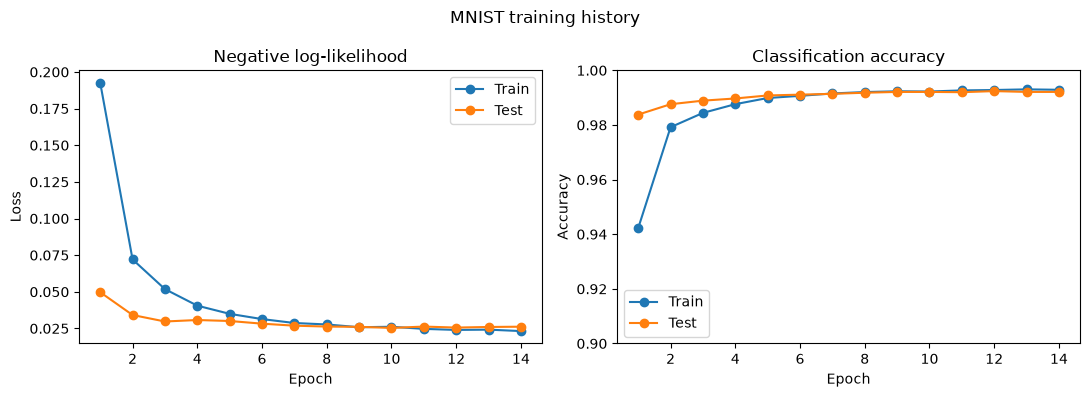

In [9]:
epochs = [row['epoch'] for row in history]
train_losses = [row['train_loss'] for row in history]
test_losses = [row['test_loss'] for row in history]
train_accuracies = [row['train_accuracy'] for row in history]
test_accuracies = [row['test_accuracy'] for row in history]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, train_losses, marker='o', label='Train')
axes[0].plot(epochs, test_losses, marker='o', label='Test')
axes[0].set(title='Negative log-likelihood', xlabel='Epoch', ylabel='Loss')
axes[0].legend()

axes[1].plot(epochs, train_accuracies, marker='o', label='Train')
axes[1].plot(epochs, test_accuracies, marker='o', label='Test')
axes[1].set(title='Classification accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=(0.90, 1.0))
axes[1].legend()

fig.suptitle('MNIST training history')
plt.tight_layout()
plt.show()


## 5. Save and verify the trained model

Saving a state dictionary keeps the artifact portable and avoids serializing Python model objects. To verify the file, this cell loads it into a new Net instance and evaluates that fresh instance.

In [10]:
torch.save(model.state_dict(), model_path)

reloaded_model = Net().to(device)
saved_state_dict = torch.load(model_path, map_location=device, weights_only=True)
reloaded_model.load_state_dict(saved_state_dict)
reloaded_model.eval()

reloaded_loss, reloaded_accuracy = evaluate(reloaded_model, test_loader, device)
model = reloaded_model

print(f'Saved weights: {model_path}')
print(f'File size: {model_path.stat().st_size / 1_000_000:.2f} MB')
print(f'Reloaded test loss: {reloaded_loss:.4f}')
print(f'Reloaded test accuracy: {reloaded_accuracy:.2%}')
assert abs(reloaded_accuracy - history[-1]['test_accuracy']) < 1e-12


Saved weights: /Users/rad/dev/minor/ml/llmsfs/torch/models/mnist_cnn_state_dict.pt
File size: 4.80 MB
Reloaded test loss: 0.0262
Reloaded test accuracy: 99.21%


## 6. Fast Gradient Sign Method

FGSM changes each input pixel in the direction that increases the model's loss:

$$
x_{adv}=\operatorname{clip}_{[0,1]}\left(x+\epsilon\,\operatorname{sign}(\nabla_x J(\theta,x,y))\right)
$$

Here x is the original image, y is its true label, theta represents the fixed model weights, and epsilon controls the maximum pixel change. The gradient is taken with respect to the input pixels—not the model parameters. Attacks are created in the original [0, 1] pixel range and normalized again before classification.

In [11]:
def normalize_pixels(images):
    return (images - MNIST_MEAN) / MNIST_STD


def denormalize(images):
    return images * MNIST_STD + MNIST_MEAN


def fgsm_attack(images, epsilon, input_gradients):
    perturbed_images = images + epsilon * input_gradients.sign()
    return perturbed_images.clamp(0, 1)


In [12]:
def evaluate_fgsm(model, loader, epsilon, device, max_examples=5):
    model.eval()
    robust_correct = 0
    examples = []

    for normalized_data, target in loader:
        normalized_data = normalized_data.to(device)
        target = target.to(device)

        pixels = denormalize(normalized_data).clamp(0, 1).detach()
        pixels.requires_grad_(True)

        output = model(normalize_pixels(pixels))
        initial_prediction = output.argmax(dim=1)
        initially_correct = initial_prediction.eq(target)

        loss = F.nll_loss(output, target, reduction='sum')
        model.zero_grad(set_to_none=True)
        loss.backward()

        adversarial_pixels = fgsm_attack(
            pixels.detach(),
            epsilon,
            pixels.grad.detach(),
        )

        with torch.no_grad():
            attacked_output = model(normalize_pixels(adversarial_pixels))
            final_prediction = attacked_output.argmax(dim=1)

        still_correct = initially_correct & final_prediction.eq(target)
        robust_correct += still_correct.sum().item()

        if epsilon == 0:
            example_mask = initially_correct
        else:
            example_mask = initially_correct & final_prediction.ne(target)

        for index in torch.nonzero(example_mask, as_tuple=False).flatten().tolist():
            if len(examples) >= max_examples:
                break
            examples.append({
                'original': initial_prediction[index].item(),
                'adversarial': final_prediction[index].item(),
                'image': adversarial_pixels[index].squeeze().cpu().numpy(),
            })

    sample_count = len(loader.dataset)
    return {
        'epsilon': epsilon,
        'correct': robust_correct,
        'accuracy': robust_correct / sample_count,
        'examples': examples,
    }


In [13]:
attack_results = []

for epsilon in EPSILONS:
    result = evaluate_fgsm(model, attack_loader, epsilon, device)
    attack_results.append(result)
    print(
        'epsilon={:.2f} | robust accuracy: {:,}/{:,} ({:.2%})'.format(
            epsilon,
            result['correct'],
            len(test_dataset),
            result['accuracy'],
        )
    )


epsilon=0.00 | robust accuracy: 9,921/10,000 (99.21%)


epsilon=0.05 | robust accuracy: 9,571/10,000 (95.71%)


epsilon=0.10 | robust accuracy: 8,575/10,000 (85.75%)


epsilon=0.15 | robust accuracy: 6,625/10,000 (66.25%)


epsilon=0.20 | robust accuracy: 3,982/10,000 (39.82%)


epsilon=0.25 | robust accuracy: 2,042/10,000 (20.42%)


epsilon=0.30 | robust accuracy: 981/10,000 (9.81%)


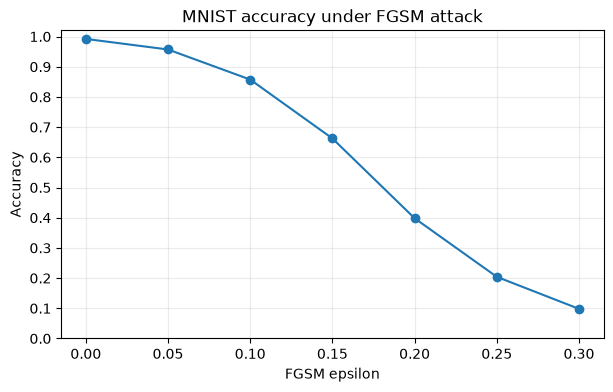

In [14]:
attack_epsilons = [result['epsilon'] for result in attack_results]
attack_accuracies = [result['accuracy'] for result in attack_results]

plt.figure(figsize=(7, 4))
plt.plot(attack_epsilons, attack_accuracies, marker='o')
plt.xticks(attack_epsilons)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1.02)
plt.xlabel('FGSM epsilon')
plt.ylabel('Accuracy')
plt.title('MNIST accuracy under FGSM attack')
plt.grid(alpha=0.25)
plt.show()


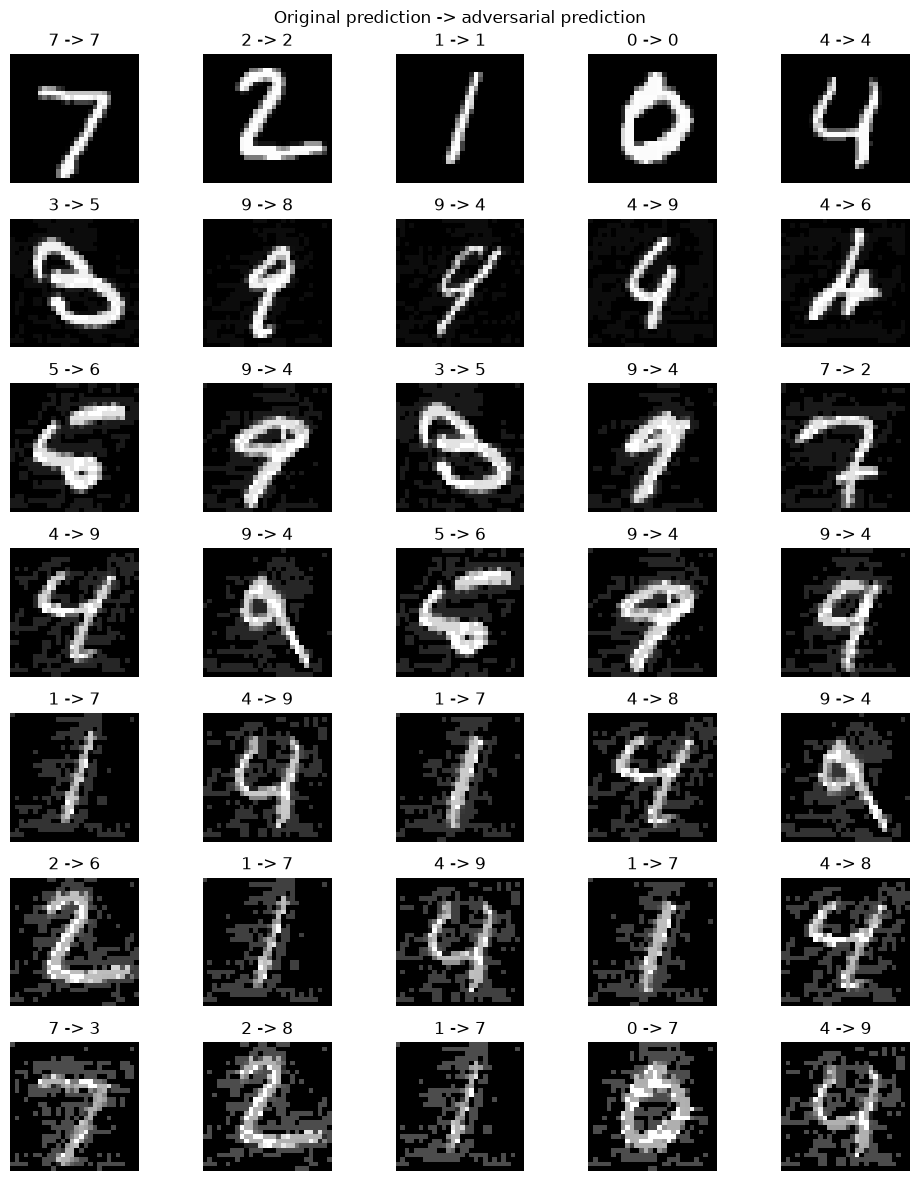

In [15]:
example_count = max(len(result['examples']) for result in attack_results)
fig, axes = plt.subplots(len(attack_results), example_count, figsize=(10, 12), squeeze=False)

for row, result in enumerate(attack_results):
    for column, axis in enumerate(axes[row]):
        axis.axis('off')
        if column >= len(result['examples']):
            continue
        example = result['examples'][column]
        axis.imshow(example['image'], cmap='gray', vmin=0, vmax=1)
        axis.set_title(f"{example['original']} -> {example['adversarial']}")
    axes[row, 0].set_ylabel(f"epsilon={result['epsilon']:.2f}")

fig.suptitle('Original prediction -> adversarial prediction')
plt.tight_layout()
plt.show()


## 7. Takeaways

- Epsilon zero is the clean-model baseline.
- Increasing epsilon permits a larger pixel perturbation and should reduce robust accuracy.
- The attack is white-box because it needs gradients through the trained model.
- The saved state dictionary can be loaded later without retraining, as long as the Net architecture is defined first.
- Re-running the training cell replaces the in-memory model; re-running the save cell deliberately replaces the saved weights.